# Exploring Diffusion Models for CT Image Generation

# 1. Motivation
In the project `brain_ct_xai.ipynb`, I explored ICH classification, uncertainty, and latent-space counterfactuals. The latent-shift experiment suggested that, in at least one case, the autoencoder reconstruction lost subtle pathological information before the counterfactual shift was applied.

This motivates exploring diffusion models as another generative approach and asking whether they can model CT images without the same reconstruction bottleneck. In particular, I want to investigate whether their iterative generation process can better preserve subtle image features.

Here, I train a small diffusion model on our CT data and explore how it generates CT-like images. This is an exploratory implementation, not a clinically validated generative model.

# 2. What is a Diffusion Model?

A diffusion model is a generative model that learns to create new data by **reversing a gradual noising process**.

During training, noise is progressively added to real images. The model learns the reverse process: starting from random noise and gradually removing it to generate a new image.

**Forward:** Real image → noisy image → random noise
**Reverse:** Random noise → denoising → generated image

<img src="./assets/diffusion_process.png" width="900">

*Figure: Forward diffusion gradually transforms \(x_0\) into noise \(x_T\), while the reverse process progressively generates an image from \(x_T\). Adapted from Ghojogh and Ghodsi (2024).*

**Reference**

Ghojogh, B., & Ghodsi, A. (2024). *Diffusion models: Tutorial and survey*. ResearchGate.
https://www.researchgate.net/figure/The-forward-and-backward-processes-of-the-diffusion-model-The-credit-of-the-used-images_fig1_382128283



# 3. Setup

In [9]:
import copy
import math
from pathlib import Path

import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F
from torch import nn
from torch.utils.data import DataLoader
from torchvision import transforms

from src.data_loading import load_diagnosis
from src.dataset import CTDiffusionDataset

# Configuration
DATA_DIR = Path("data")
IMAGE_SIZE = 128
BATCH_SIZE = 64
T = 1000


# 3. CT Data Preparation

We use the same CT dataset as in the main project.

For this exploratory experiment, images are:

* converted to **grayscale**
* resized to **128 × 128**
* normalized to **[-1, 1]**

The reduced resolution keeps the experiment computationally feasible while preserving more anatomical detail than a 64 × 64 representation. For a more detailed medical application, the resolution could be increased further to better preserve subtle anatomical and pathological information.


In [10]:
# Image preprocessing
transform = transforms.Compose(
    [
        transforms.Grayscale(num_output_channels=1),
        transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
        transforms.ToTensor(),
        transforms.Normalize((0.5,), (0.5,)),
    ]
)


# Load metadata
diagnosis_df = load_diagnosis(DATA_DIR)

print(diagnosis_df.shape)
print(diagnosis_df.columns.tolist())


# Create dataset
dataset = CTDiffusionDataset(
    diagnosis_df=diagnosis_df,
    data_dir=DATA_DIR,
    transform=transform,
)


# Create data loader
dataloader = DataLoader(
    dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
)

print(f"Number of images: {len(dataset)}")


# Inspect a batch
images = next(iter(dataloader))

print(f"Batch shape: {images.shape}")
print(f"Min value: {images.min():.3f}")
print(f"Max value: {images.max():.3f}")


(2501, 9)
['PatientNumber', 'SliceNumber', 'Intraventricular', 'Intraparenchymal', 'Subarachnoid', 'Epidural', 'Subdural', 'No_Hemorrhage', 'Fracture_Yes_No']
Number of images: 2501
Batch shape: torch.Size([64, 1, 128, 128])
Min value: -1.000
Max value: 1.000


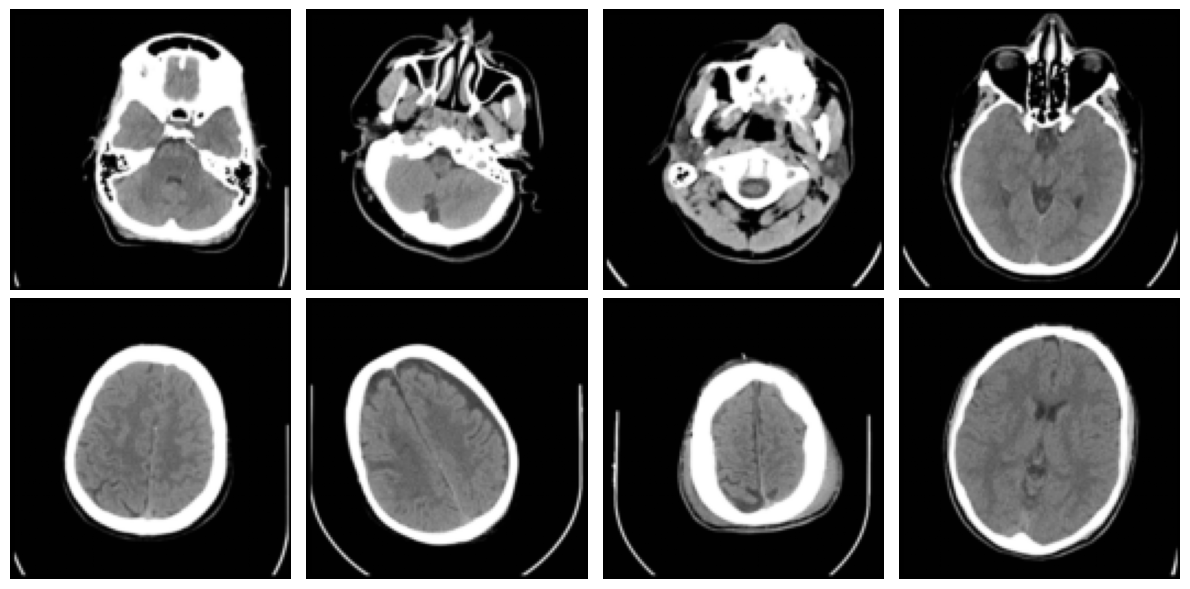

In [11]:
# Visualize sample images
fig, axes = plt.subplots(2, 4, figsize=(12, 6))

for ax, image in zip(axes.flat, images[:8]):
    image = image.squeeze(0)
    image = (image + 1) / 2

    ax.imshow(image, cmap="gray")
    ax.axis("off")

plt.tight_layout()
plt.show()


# 4. Forward Diffusion

Forward diffusion gradually adds **Gaussian noise** to a clean CT image.

Starting from the original image $`x_0`$, I generate increasingly noisy versions until the image becomes almost pure noise $`x_T`$.

In this section, I will:

* define the **noise schedule**
* implement the **forward diffusion process**
* visualize how the CT image changes at different timesteps

$$
x_0 \rightarrow x_1 \rightarrow \cdots \rightarrow x_T
$$

The model will later learn to reverse this process.


In [12]:
def cosine_beta_schedule(T, s=0.008):
    """
    Nichol & Dhariwal (2021), "Improved Denoising Diffusion Probabilistic Models".
    Produces a smoother SNR curve than the linear schedule, wasting fewer
    steps at very high signal-to-noise ratios (useful for small/low-res data).
    """
    steps = T + 1
    x = torch.linspace(0, T, steps)
    alphas_cumprod = torch.cos(((x / T) + s) / (1 + s) * math.pi * 0.5) ** 2
    alphas_cumprod = alphas_cumprod / alphas_cumprod[0]
    betas = 1 - (alphas_cumprod[1:] / alphas_cumprod[:-1])
    return torch.clip(betas, 1e-4, 0.999)


In [13]:
# Diffusion parameters

beta_start = 1e-4
beta_end = 0.02

betas = cosine_beta_schedule(T)

alphas = 1.0 - betas
alpha_bars = torch.cumprod(alphas, dim=0)

# Add noise to an image at timestep t
def add_noise(x0, t):
    noise = torch.randn_like(x0)
    alpha_bar = alpha_bars[t.cpu()].to(x0.device).view(-1, 1, 1, 1)
    xt = torch.sqrt(alpha_bar) * x0 + torch.sqrt(1 - alpha_bar) * noise
    return xt, noise

# Test forward diffusion
x0 = images[:1]

t = torch.tensor([500])

xt, noise = add_noise(x0, t)

print(f"Original shape: {x0.shape}")
print(f"Noisy shape: {xt.shape}")

Original shape: torch.Size([1, 1, 128, 128])
Noisy shape: torch.Size([1, 1, 128, 128])


# 5. Visualizing Noise Addition

I now visualize how the same CT image changes as more noise is added.

The timestep \(t\) represents the **amount of noise added so far** in the diffusion process. With \(T=1000\):

* \(t=0\): original clean image
* \(t=300\): moderately noisy image
* \(t=500\): substantially noisy image
* \(t=700\): mostly noisy image
* \(t=999\): almost pure random noise

As the timestep increases, less information from the original image is preserved.

$$
x_0 \rightarrow x_{100} \rightarrow x_{300} \rightarrow x_{500} \rightarrow x_{700} \rightarrow x_{999}
$$



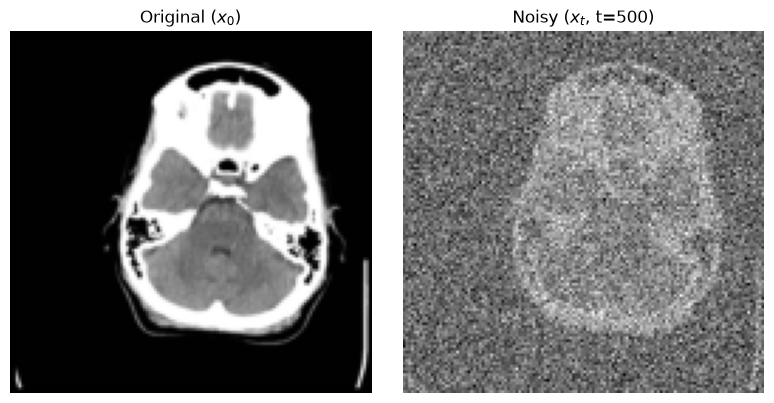

In [14]:
# Visualize original and noisy images
fig, axes = plt.subplots(1, 2, figsize=(8, 4))

# Original image
axes[0].imshow((x0[0, 0] + 1) / 2, cmap="gray")
axes[0].set_title("Original ($x_0$)")
axes[0].axis("off")

# Noisy image
axes[1].imshow((xt[0, 0] + 1) / 2, cmap="gray")
axes[1].set_title(f"Noisy ($x_t$, t={t.item()})")
axes[1].axis("off")

plt.tight_layout()
plt.show()

# 6. Building a Small DDPM

I now build a small **Denoising Diffusion Probabilistic Model (DDPM)** that learns to reverse the noising process.

The model receives a noisy CT image $`x_t`$ and its timestep $`t`$, and learns to **predict the added noise**.

During generation, it repeatedly removes noise to produce a new CT image.

### Towards Counterfactuals

By adding a target condition during denoising, diffusion models can potentially generate **controlled counterfactuals**:

$$
\text{No ICH} \rightarrow \text{denoise toward ICH} \rightarrow \text{ICH counterfactual}
$$

Our current model focuses only on basic image generation; counterfactual generation is a future extension.


In [15]:
class SinusoidalTimeEmbedding(nn.Module):
    """Transformer-style sinusoidal embedding — much richer signal than t/1000
    through a couple of linear layers, and it's essentially free."""

    def __init__(self, dim):
        super().__init__()
        self.dim = dim

    def forward(self, t):
        device = t.device
        half_dim = self.dim // 2
        freqs = torch.exp(
            -math.log(10000) * torch.arange(half_dim, device=device) / (half_dim - 1)
        )
        args = t.float()[:, None] * freqs[None, :]
        return torch.cat([torch.sin(args), torch.cos(args)], dim=-1)


class ResidualBlock(nn.Module):
    """
    Conv -> GroupNorm -> SiLU, with the timestep embedding injected via a
    FiLM-style scale/shift at EVERY block (not just once at the bottleneck),
    plus a residual connection inside the block itself.
    """

    def __init__(self, in_ch, out_ch, time_emb_dim, groups=8):
        super().__init__()
        self.norm1 = nn.GroupNorm(min(groups, in_ch), in_ch)
        self.conv1 = nn.Conv2d(in_ch, out_ch, 3, padding=1)

        self.time_proj = nn.Linear(time_emb_dim, out_ch * 2)  # scale + shift

        self.norm2 = nn.GroupNorm(min(groups, out_ch), out_ch)
        self.conv2 = nn.Conv2d(out_ch, out_ch, 3, padding=1)

        self.skip = nn.Conv2d(in_ch, out_ch, 1) if in_ch != out_ch else nn.Identity()

    def forward(self, x, t_emb):
        h = self.conv1(F.silu(self.norm1(x)))

        scale, shift = self.time_proj(t_emb).chunk(2, dim=-1)
        h = h * (1 + scale[:, :, None, None]) + shift[:, :, None, None]

        h = self.conv2(F.silu(self.norm2(h)))
        return h + self.skip(x)


class SelfAttention2d(nn.Module):
    """Standard single-head QKV self-attention over spatial positions.
    Helps capture global structure (e.g. left-right symmetry) that
    convolutions alone struggle to enforce."""

    def __init__(self, channels):
        super().__init__()
        self.norm = nn.GroupNorm(8, channels)
        self.qkv = nn.Conv2d(channels, channels * 3, 1)
        self.proj = nn.Conv2d(channels, channels, 1)

    def forward(self, x):
        b, c, h, w = x.shape
        qkv = self.qkv(self.norm(x))
        q, k, v = qkv.chunk(3, dim=1)
        q = q.reshape(b, c, h * w).permute(0, 2, 1)  # (b, hw, c)
        k = k.reshape(b, c, h * w)  # (b, c, hw)
        v = v.reshape(b, c, h * w).permute(0, 2, 1)  # (b, hw, c)

        attn = torch.softmax(q @ k / math.sqrt(c), dim=-1)  # (b, hw, hw)
        out = (attn @ v).permute(0, 2, 1).reshape(b, c, h, w)
        return x + self.proj(out)


class SmallUNet(nn.Module):
    def __init__(self, time_dim=128, base_ch=32, num_classes=None):
        super().__init__()
        self.time_mlp = nn.Sequential(
            SinusoidalTimeEmbedding(time_dim),
            nn.Linear(time_dim, time_dim),
            nn.SiLU(),
            nn.Linear(time_dim, time_dim),
        )

        # 12. Class conditioning (optional): pass class label ids at train
        # time (e.g. 0 = non-ICH, 1 = ICH) alongside the timestep. This is a
        # stepping stone toward conditional counterfactual generation later.
        self.num_classes = num_classes
        if num_classes is not None:
            self.class_emb = nn.Embedding(num_classes, time_dim)

        ch1, ch2, ch3, ch4 = base_ch, base_ch * 2, base_ch * 4, base_ch * 8

        self.in_conv = nn.Conv2d(1, ch1, 3, padding=1)

        # 9. One extra downsampling stage vs. the original (128->64->32->16)
        self.down1 = ResidualBlock(ch1, ch1, time_dim)
        self.down2 = ResidualBlock(ch1, ch2, time_dim)
        self.down3 = ResidualBlock(ch2, ch3, time_dim)
        self.pool = nn.MaxPool2d(2)

        self.bottleneck1 = ResidualBlock(ch3, ch4, time_dim)
        self.attn = SelfAttention2d(ch4)  # 8. attention at 16x16
        self.bottleneck2 = ResidualBlock(ch4, ch4, time_dim)

        self.up3 = nn.ConvTranspose2d(ch4, ch3, 2, stride=2)
        self.dec3 = ResidualBlock(ch3 * 2, ch3, time_dim)

        self.up2 = nn.ConvTranspose2d(ch3, ch2, 2, stride=2)
        self.dec2 = ResidualBlock(ch2 * 2, ch2, time_dim)

        self.up1 = nn.ConvTranspose2d(ch2, ch1, 2, stride=2)
        self.dec1 = ResidualBlock(ch1 * 2, ch1, time_dim)

        self.out_norm = nn.GroupNorm(8, ch1)
        self.out_conv = nn.Conv2d(ch1, 1, 3, padding=1)

    def forward(self, x, t, y=None):
        t_emb = self.time_mlp(t)
        if self.num_classes is not None and y is not None:
            t_emb = t_emb + self.class_emb(y)

        x0 = self.in_conv(x)
        x1 = self.down1(x0, t_emb)
        x2 = self.down2(self.pool(x1), t_emb)
        x3 = self.down3(self.pool(x2), t_emb)

        b = self.bottleneck1(self.pool(x3), t_emb)
        b = self.attn(b)
        b = self.bottleneck2(b, t_emb)

        u = self.up3(b)
        u = self.dec3(torch.cat([u, x3], dim=1), t_emb)

        u = self.up2(u)
        u = self.dec2(torch.cat([u, x2], dim=1), t_emb)

        u = self.up1(u)
        u = self.dec1(torch.cat([u, x1], dim=1), t_emb)

        return self.out_conv(F.silu(self.out_norm(u)))


class EMA:
    def __init__(self, model, decay=0.999):
        self.decay = decay
        self.ema_model = copy.deepcopy(model).eval()
        for p in self.ema_model.parameters():
            p.requires_grad_(False)

    @torch.no_grad()
    def update(self, model):
        for ema_p, p in zip(self.ema_model.parameters(), model.parameters()):
            ema_p.mul_(self.decay).add_(p, alpha=1 - self.decay)
        for ema_b, b in zip(self.ema_model.buffers(), model.buffers()):
            ema_b.copy_(b)

    def state_dict(self):
        return self.ema_model.state_dict()


def train(model, dataloader, optimizer, criterion, device, epochs, T):
    ema = EMA(model, decay=0.999)

    model.train()
    for epoch in range(epochs):
        total_loss = 0.0

        for x0 in dataloader:
            x0 = x0.to(device)
            t = torch.randint(0, T, (x0.size(0),), device=device)

            xt, noise = add_noise(x0, t)  # no more .cpu() needed, see fix above
            predicted_noise = model(xt, t)

            loss = criterion(predicted_noise, noise)

            optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)  # 6.
            optimizer.step()

            ema.update(model)  # 1.

            total_loss += loss.item()

        average_loss = total_loss / len(dataloader)
        print(f"Epoch {epoch + 1}/{epochs} - Loss: {average_loss:.4f}")

    return ema  # sample from ema.ema_model, not from `model`


# Create the diffusion model
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = SmallUNet(time_dim=128, base_ch=32, num_classes=None).to(device)

print(f"Using device: {device}")


Using device: cpu


In [16]:
# Sanity check: verify one forward pass, loss computation, backward pass, and optimizer update

criterion = nn.MSELoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4)

model.train()

# Get one batch
x0 = next(iter(dataloader)).to(device)

# Sample a random timestep for each image
t = torch.randint(0, T, (x0.size(0),), device=device)

# Add noise
xt, noise = add_noise(x0, t)

# Predict the added noise
predicted_noise = model(xt, t)

# Compute loss
loss = criterion(predicted_noise, noise)

# Backward pass and parameter update
optimizer.zero_grad()
loss.backward()
torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
optimizer.step()

print(f"Input shape: {x0.shape}")
print(f"Noisy input shape: {xt.shape}")
print(f"Predicted noise shape: {predicted_noise.shape}")
print(f"Training loss: {loss.item():.4f}")

Input shape: torch.Size([64, 1, 128, 128])
Noisy input shape: torch.Size([64, 1, 128, 128])
Predicted noise shape: torch.Size([64, 1, 128, 128])
Training loss: 1.1066


# 7. Training

The model is trained to **predict the noise** added to a CT image.

For each training step, I:

1. Sample a random timestep \(t\).
2. Add the corresponding amount of noise to the image.
3. Give the noisy image and \(t\) to the U-Net.
4. Compare the predicted noise with the actual noise.
5. Update the model using the **MSE loss**.

By repeating this process, the model learns to predict noise at different stages of the diffusion process.


In [17]:
# Train the diffusion model using the training function with EMA

EPOCHS = 20
LEARNING_RATE = 1e-4

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=LEARNING_RATE,
)

criterion = nn.MSELoss()

ema = train(
    model=model,
    dataloader=dataloader,
    optimizer=optimizer,
    criterion=criterion,
    device=device,
    epochs=EPOCHS,
    T=T,
)

Epoch 1/20 - Loss: 0.4747
Epoch 2/20 - Loss: 0.1307
Epoch 3/20 - Loss: 0.1036
Epoch 4/20 - Loss: 0.0841
Epoch 5/20 - Loss: 0.0708
Epoch 6/20 - Loss: 0.0714
Epoch 7/20 - Loss: 0.0621
Epoch 8/20 - Loss: 0.0589
Epoch 9/20 - Loss: 0.0579
Epoch 10/20 - Loss: 0.0544
Epoch 11/20 - Loss: 0.0536
Epoch 12/20 - Loss: 0.0529
Epoch 13/20 - Loss: 0.0504
Epoch 14/20 - Loss: 0.0467
Epoch 15/20 - Loss: 0.0469
Epoch 16/20 - Loss: 0.0448
Epoch 17/20 - Loss: 0.0443
Epoch 18/20 - Loss: 0.0456
Epoch 19/20 - Loss: 0.0438
Epoch 20/20 - Loss: 0.0430


# 8. Reverse Diffusion

The model has learned to predict the noise added to a CT image.

I now use this ability to reverse the diffusion process:

$$
x_T \rightarrow x_{T-1} \rightarrow \cdots \rightarrow x_0
$$

I start from random noise and repeatedly remove predicted noise until a new CT-like image is generated.


In [18]:
@torch.no_grad()
def reverse_step(model, xt, t):
    # Create timestep tensor
    t_batch = torch.full(
        (xt.size(0),),
        t,
        device=xt.device,
        dtype=torch.long,
    )

    # Predict the noise
    predicted_noise = model(xt, t_batch)

    # Get diffusion parameters
    beta_t = betas[t].to(xt.device)
    alpha_t = alphas[t].to(xt.device)
    alpha_bar_t = alpha_bars[t].to(xt.device)

    # Compute the reverse-process mean
    mean = (
        1
        / torch.sqrt(alpha_t)
        * (xt - (beta_t / torch.sqrt(1 - alpha_bar_t)) * predicted_noise)
    )

    # No additional noise at the final step
    if t == 0:
        return mean

    # Compute the posterior variance
    alpha_bar_prev = alpha_bars[t - 1].to(xt.device)

    posterior_variance = beta_t * (1 - alpha_bar_prev) / (1 - alpha_bar_t)

    # Add stochastic noise
    noise = torch.randn_like(xt)

    return mean + torch.sqrt(posterior_variance) * noise


@torch.no_grad()
def generate_images(model, num_images=4):
    model.eval()

    # Start from random noise
    x = torch.randn(
        num_images,
        1,
        IMAGE_SIZE,
        IMAGE_SIZE,
        device=device,
    )

    # Gradually remove noise
    for t in reversed(range(T)):
        x = reverse_step(model, x, t)

    return x


@torch.no_grad()
def ddim_sample(model, num_images, image_size, device, T, ddim_steps=50, eta=0.0):
    """
    eta=0.0 -> fully deterministic DDIM.
    Set eta=1.0 to recover standard DDPM-style stochastic sampling.
    """
    step_indices = torch.linspace(0, T - 1, ddim_steps, dtype=torch.long).flip(0)

    x = torch.randn(num_images, 1, image_size, image_size, device=device)

    for i, t in enumerate(step_indices):
        t_batch = torch.full((num_images,), t, device=device, dtype=torch.long)
        predicted_noise = model(x, t_batch)

        alpha_bar_t = alpha_bars[t].to(device)
        alpha_bar_prev = (
            alpha_bars[step_indices[i + 1]].to(device)
            if i + 1 < len(step_indices)
            else torch.tensor(1.0, device=device)
        )

        # predicted x0
        x0_pred = (x - torch.sqrt(1 - alpha_bar_t) * predicted_noise) / torch.sqrt(
            alpha_bar_t
        )
        x0_pred = x0_pred.clamp(-1, 1)

        sigma = eta * torch.sqrt(
            (1 - alpha_bar_prev)
            / (1 - alpha_bar_t)
            * (1 - alpha_bar_t / alpha_bar_prev)
        )
        dir_xt = torch.sqrt(1 - alpha_bar_prev - sigma**2) * predicted_noise
        noise = torch.randn_like(x) if eta > 0 else 0.0

        x = torch.sqrt(alpha_bar_prev) * x0_pred + dir_xt + sigma * noise

    return x


## 8.1 Testing the Learned Denoising

Before generating images from random noise, I test whether the model can denoise a real CT image.

I start with a real CT image, add noise at a chosen timestep, and ask the model to predict the noise. I then use this prediction to estimate the original image.

This helps us understand what the model has learned before running the complete reverse diffusion process.


[W911 08:59:59.983802747 NNPACK.cpp:56] Could not initialize NNPACK! Reason: Unsupported hardware.


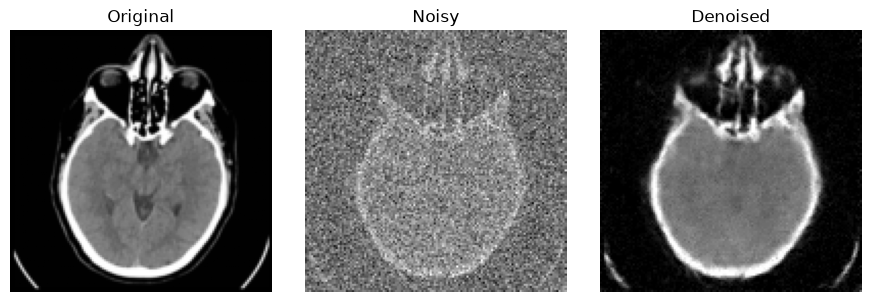

In [19]:
@torch.no_grad()
def test_denoising(model, x0, t):
    model.eval()

    # Add noise
    xt, _ = add_noise(x0, t)
    xt = xt.to(device)

    # Predict the noise
    predicted_noise = model(xt, t.to(device))

    # Estimate the clean image
    alpha_bar_t = alpha_bars[t].to(device).view(-1, 1, 1, 1)

    x0_pred = (xt - torch.sqrt(1 - alpha_bar_t) * predicted_noise) / torch.sqrt(
        alpha_bar_t
    )

    return xt, x0_pred

# Test denoising on a real CT image
x0 = images[3:4].to(device)
t = torch.tensor([500], device=device)

xt, x0_pred = test_denoising(model, x0, t)

fig, axes = plt.subplots(1, 3, figsize=(9, 3))

axes[0].imshow((x0[0, 0].cpu() + 1) / 2, cmap="gray")
axes[0].set_title("Original")
axes[0].axis("off")

axes[1].imshow((xt[0, 0].cpu() + 1) / 2, cmap="gray")
axes[1].set_title("Noisy")
axes[1].axis("off")

axes[2].imshow(
    (x0_pred[0, 0].cpu().clamp(-1, 1) + 1) / 2,
    cmap="gray",
)
axes[2].set_title("Denoised")
axes[2].axis("off")

plt.tight_layout()
plt.show()

## 8.2 Generating from Random Noise

I now visualize the images generated by the diffusion model.

These images are created starting from random noise, without using a real CT image as input.

The goal is to see whether the model has learned basic **CT-like anatomical structure** from the training data.


In [20]:
# Generate new CT-like images
samples = ddim_sample(
    ema.ema_model, num_images=4, image_size=IMAGE_SIZE, device=device,
    T=T, ddim_steps=50, eta=0.0,
)

print(f"Generated shape: {samples.shape}")

Generated shape: torch.Size([4, 1, 128, 128])


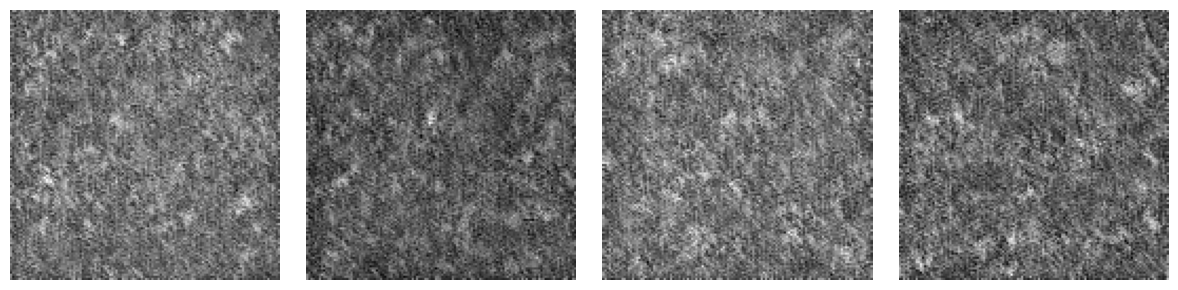

In [21]:
# Visualize generated images
samples = (samples.clamp(-1, 1) + 1) / 2

fig, axes = plt.subplots(1, 4, figsize=(12, 3))

for ax, image in zip(axes, samples):
    ax.imshow(image[0].cpu(), cmap="gray")
    ax.axis("off")

plt.tight_layout()
plt.show()

## 9. What Did I Learn?

i learned the main idea behind diffusion models:

* Noise is gradually added to real images.
* A neural network learns to predict the added noise.
* The learned model can then reverse this process to generate new images.

Our experiment also showed that **generation quality depends strongly on the model capacity and the amount and diversity of training data**.

The generated images did not reach the fidelity of real CT scans. Given the lightweight U-Net and limited patient data used in this experiment, this result is expected and mainly demonstrates the need for **larger models and more diverse data** when aiming for high-quality CT generation.


# 10. Why Diffusion for Medical AI?

Diffusion models could be useful in medical AI for:

* **Synthetic image generation:** creating additional training examples.
* **Data augmentation:** generating variations of existing images.
* **Image reconstruction:** recovering or improving image information.
* **Conditional generation:** generating images with a desired property.
* **Counterfactuals:** potentially changing a pathological condition while preserving the patient's anatomy.

For our project, the most interesting direction is **conditional counterfactual generation**: generating an image that changes the predicted condition while preserving the underlying anatomy.


# 11. Limitations & Next Steps

Our experiment has several important limitations:

* **Limited data:** a small number of patients makes it difficult to learn the full variability of CT images.
* **Simple model:** our lightweight U-Net has limited capacity to capture complex anatomical details.
* **Computational cost:** diffusion models require many denoising steps and can be expensive to train and generate.
* **Medical fidelity:** generated images must preserve realistic anatomy and pathology, which requires much stronger validation than visual inspection.
* **Bias:** generated images can reflect biases present in the training data.

Our generated images were therefore **not sufficiently faithful to real CT scans**.

This leaves an open question for future work:

> **Can more advanced diffusion models generate medically faithful CT images while providing useful control for counterfactual generation?**
